In [1]:
import pandas as pd
from pathlib import Path
from datetime import datetime
from torch.utils.data import DataLoader
from amoc_reconstruction.reconstruction.model import init_assignment_module
from amoc_reconstruction.reconstruction.model import ProfileModelSUSTeR5_fast, ProfileModelSUSTeR6, ProfileModelSUSTeR7
from amoc_reconstruction.train import train, make_predictions
from amoc_reconstruction.reconstruction.dataset import merge_profiles_max_profiles
from amoc_reconstruction.reconstruction.dataset import load_merged_argo_dataset_and_tumo_cycles, filter_ds_argo_data, split_dataset_into_training_validation_testing_profile_datasets
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import torch

In [2]:
### PARAMETERS

smoothing_days = 90

time_smoothing = f'{smoothing_days}D'
lat_bounds = (25, 30)

test_start_year = 1988
test_end_year = 1998
validation_years_on_each_side = 5


target_reference_level = 4800

missing_values_in_target = False


using_missing_indices = False
using_transport_from_previous_year = False
use_deep_dvdz = False
deep_argo = True

geostrophic_prediction = False


train_batch_sizes = {
    '10D': 32,
    '30D': 16,
    '90D': 8,
    '365D': 4,
}


n_compartments_for_smoothing = {
    '10D': 49,
    '30D': 3,
    '90D': 9,
    '365D': 42,
}

train_batch_size = train_batch_sizes[time_smoothing]

add_tmp = False
add_sal = False

test_start_year = 2005
test_end_year = 2025

validation_years_on_each_side = 10


random_split_data = False

assert target_reference_level in [2000, 4800], "Only 2000 and 4800 are supported as reference levels"
version = 'v5'
n_compartments = n_compartments_for_smoothing[time_smoothing]
n_embedding = 8

distance_assignment_module  = 'distance'

experiment_path = Path(f'../rapid-geostrophic-reconstruction/figs/experiment_{datetime.now().strftime("%Y%m%d_%H%M%S")}')
dataset_path = Path(f'../rapid-geostrophic-reconstruction/datasets/smoothing_{smoothing_days}_days/argo_after_2012/paperdraft/')

total_moc_path = Path('../rapid-geostrophic-reconstruction/datasets/moc_total/')
antilles_current_path = Path('../rapid-geostrophic-reconstruction/datasets/antilles_current/')
florida_current_path = Path('../rapid-geostrophic-reconstruction/datasets/florida_current/')
wind_stress_path = Path('../rapid-geostrophic-reconstruction/datasets/windstress/')

ref_folder = f'{abs(target_reference_level)}m_ref'

compartments = [
        ['west_p', -76.74, -70, 'west'],
        ['mar_west_p', -60, -47, 'east'],
        ['mar_east_p', -47, -40, 'west'],
        ['east_p', -30, -13.5, 'east']
    ]


device = 'cpu'


assert version in ['v2', 'v3', 'v4', 'v5']
assert distance_assignment_module in ['distance', 'fixed']



In [3]:



ds_argo_merged, t_umo_obs, ds_pos_sim, dv_dz_obs, t_delta, total_moc, antilles_current, florida_current, wind_stress, backwards_timeshift = load_merged_argo_dataset_and_tumo_cycles(
    # ['1st_7020', '2nd_5820', '3rd_5820', '4th_5820', '5th_5820', '6th_5820'],
    ['1st_7020'],
    dataset_path,
    ref_folder,
    total_moc_path,
    antilles_current_path,
    florida_current_path,
    wind_stress_path,
    time_smoothing,
    deep_argo,
    missing_values_in_target
)


ds_argo_merged = filter_ds_argo_data(ds_argo_merged, deep_argo)





train_dataset, val_dataset, test_dataset, (total_moc_mean, total_moc_std, geostrophic_moc_mean, geostorphic_moc_std) = split_dataset_into_training_validation_testing_profile_datasets(
    False, test_start_year, test_end_year, validation_years_on_each_side, t_umo_obs, ds_argo_merged, add_tmp, add_sal, deep_argo, False, total_moc, florida_current, antilles_current, wind_stress, dv_dz_obs, missing_values_in_target, ds_pos_sim, compartments, time_smoothing, lat_bounds, using_transport_from_previous_year, using_missing_indices, use_deep_dvdz, backwards_timeshift
)


dl = DataLoader(train_dataset, batch_size=train_batch_size, shuffle=True, collate_fn=merge_profiles_max_profiles, num_workers=0)
val_dl = DataLoader(val_dataset, batch_size=32, shuffle=False, collate_fn=merge_profiles_max_profiles, num_workers=0)
test_dl = DataLoader(test_dataset, batch_size=32, shuffle=False, collate_fn=merge_profiles_max_profiles, num_workers=0)


/gxfs_home/geomar/smomw507/.conda/envs/amoc_recons/lib/python3.9/site-packages/xarray/coding/times.py:254: RuntimeWarning: invalid value encountered in cast
  flat_num_dates_ns_int = (flat_num_dates * _NS_PER_TIME_DELTA[delta]).astype(
/gxfs_home/geomar/smomw507/.conda/envs/amoc_recons/lib/python3.9/site-packages/xarray/coding/times.py:254: RuntimeWarning: invalid value encountered in cast
  flat_num_dates_ns_int = (flat_num_dates * _NS_PER_TIME_DELTA[delta]).astype(
/gxfs_home/geomar/smomw507/.conda/envs/amoc_recons/lib/python3.9/site-packages/xarray/coding/times.py:254: RuntimeWarning: invalid value encountered in cast
  flat_num_dates_ns_int = (flat_num_dates * _NS_PER_TIME_DELTA[delta]).astype(
/gxfs_home/geomar/smomw507/.conda/envs/amoc_recons/lib/python3.9/site-packages/xarray/coding/times.py:254: RuntimeWarning: invalid value encountered in cast
  flat_num_dates_ns_int = (flat_num_dates * _NS_PER_TIME_DELTA[delta]).astype(
/gxfs_home/geomar/smomw507/.conda/envs/amoc_recons/lib/p

142 202 2005-03-28T00:00:00.000000000 2020-01-09T00:00:00.000000000
101 41 61


/gxfs_home/geomar/smomw507/.conda/envs/amoc_recons/lib/python3.9/site-packages/numpy/lib/nanfunctions.py:1879: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/gxfs_home/geomar/smomw507/.conda/envs/amoc_recons/lib/python3.9/site-packages/numpy/lib/nanfunctions.py:1879: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/gxfs_home/geomar/smomw507/.conda/envs/amoc_recons/lib/python3.9/site-packages/numpy/lib/nanfunctions.py:1879: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/gxfs_home/geomar/smomw507/.conda/envs/amoc_recons/lib/python3.9/site-packages/numpy/lib/nanfunctions.py:1879: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/gxfs_home/geomar/smomw507/.conda/envs/amoc_recons/lib/python3.9/site-packages/numpy/lib/nanfunctions.py

(203, 142)

In [ ]:
train_indices

[]

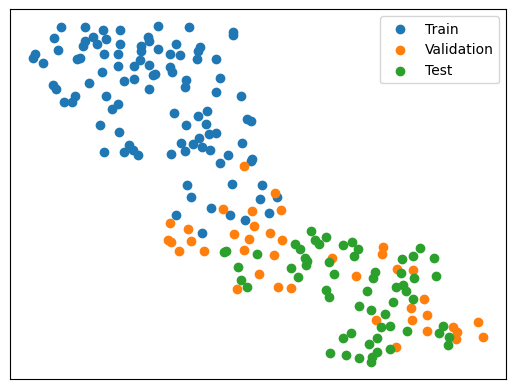

In [28]:
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

fig = plt.figure()
ax = fig.add_subplot(1,1,1)
pca = PCA(n_components=2)
pca.fit(train_dataset.dv_dz)

# reduced_values = pca.transform(dv_dz_obs.dv_dz_times_X.sel(z = slice(None, -2000)).values)
reduced_values = TSNE(n_components=2).fit_transform(dv_dz_obs.dv_dz_times_X.sel(z = slice(None, -2000)).values)

ax.scatter(reduced_values[train_dataset.global_indices,0], reduced_values[train_dataset.global_indices,1], label = 'Train')
ax.scatter(reduced_values[val_dataset.global_indices,0], reduced_values[val_dataset.global_indices,1], label = 'Validation')
ax.scatter(reduced_values[test_dataset.global_indices,0], reduced_values[test_dataset.global_indices,1], label = 'Test')
ax.legend()

ax.set_xticks([])
ax.set_yticks([])

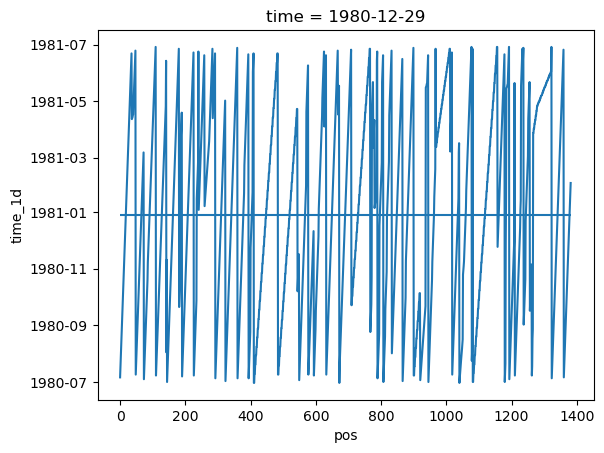

In [13]:
import matplotlib.pyplot as plt

fig = plt.figure()
ax = fig.add_subplot(1,1,1)

ds_argo_merged.isel(time = 10).time_1d.plot(ax = ax)
ax.hlines(y = ds_argo_merged.isel(time = 10).time, xmin = 0, xmax = ds_argo_merged.isel(time = 10, z = -1).profile_mask.sum())

In [15]:
import xarray as xr

xr.open_dataset('../rapid-geostrophic-reconstruction/datasets/smoothing_365_days/ds_argo_obs.nc')

<xarray.Dataset>
Dimensions:       (time: 24, z: 242, pos: 2454)
Coordinates:
  * time          (time) datetime64[ns] 2000-12-24 2001-12-24 ... 2023-12-19
  * z             (z) float64 -0.0 -20.0 -40.0 ... -4.78e+03 -4.8e+03 -4.82e+03
    pressure      (z) float64 ...
    lon           (time, pos) float64 ...
    lat           (time, pos) float64 ...
    time_1d       (time, pos) datetime64[ns] ...
  * pos           (pos) int64 0 1 2 3 4 5 6 ... 2448 2449 2450 2451 2452 2453
Data variables:
    temperature   (time, z, pos) float64 ...
    salinity      (time, z, pos) float64 ...
    profile_mask  (time, pos) float64 ...
    ct            (time, z, pos) float64 ...
    rho           (time, z, pos) float64 ...

In [4]:
len(dl), len(val_dl), len(test_dl)

(167, 2, 3)

Text(0, 0.5, 'Total MOC normalized')

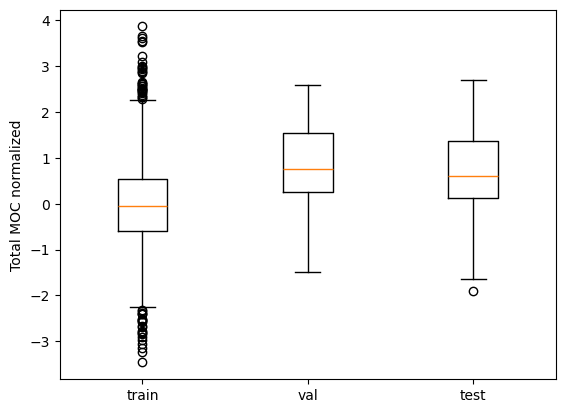

In [4]:
import matplotlib.pyplot as plt
fig = plt.figure()
ax = fig.add_subplot(1,1,1)

ax.boxplot(train_dataset.total_moc, positions=[1], widths=0.3)
ax.boxplot(val_dataset.total_moc, positions=[2], widths=0.3)
ax.boxplot(test_dataset.total_moc, positions=[3], widths=0.3)

ax.set_xticklabels(['train', 'val', 'test'])
ax.set_ylabel('Total MOC normalized')


In [4]:
for i in range(5):
    sample_i = train_dataset[i]
    print(sample_i[-2])

[1.4207671  1.0510738  1.1470832  1.7330713  2.2720606  2.0858564
 2.076854   1.9429463  1.0839221  0.77155143]
[-0.7553983   0.0292556   0.23662224  0.1000464  -0.28216472 -0.3566371
 -0.41989818 -0.53759986 -0.3590811  -0.17409904]
[-0.97850394 -0.949055   -1.257379   -1.06402    -1.2158993  -1.3972356
 -1.2400867  -1.0323838  -0.624433   -0.8929842 ]
[-0.48575988  0.02743934  0.42730108  0.9075276   0.9507842   0.742903
  0.6759865   0.21169147 -0.2637327   0.08602432]
[1.4789298  1.1572206  0.9449288  0.72545564 0.29560763 0.0922575
 0.1331032  0.2619096  0.51102054 0.5864613 ]


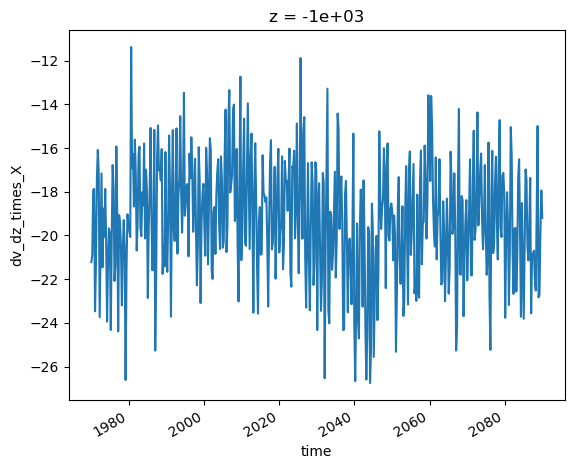

In [5]:
t_umo_obs.dv_dz_times_X.plot()

In [6]:
def get_means(dataloader):
    argo_means = []

    moc_strength = []
    masks = []

    for data in dataloader:
        X, mask_padded, y, y_prev, lon, lat, dvdz, days, missing_indices, fs, ac, ws, total_moc = data
        print(X.shape)

        argo_mean = torch.sum(X, dim=1) / torch.sum(mask_padded, dim=1, keepdim=True)

        argo_std = torch.sqrt(((X - argo_mean.unsqueeze(1)) ** 2).sum(dim = 1) / (torch.sum(mask_padded, dim=1, keepdim=True) - 1))

        mask = (argo_std < 5).all(1)


        argo_means.append(argo_mean[mask])
        moc_strength.append(total_moc[mask])
        masks.append(mask)

    masks = torch.cat(masks, dim = 0)     
    argo_means = torch.cat(argo_means, dim=0)
    moc_strength = torch.cat(moc_strength, dim=0)

    return argo_means, moc_strength, ds_argo_merged.isel(time = dataloader.dataset.global_indices).time.dt.year[masks]


train_argo_means, train_moc_strength, train_years = get_means(DataLoader(train_dataset, batch_size=32, shuffle=False, collate_fn=merge_profiles_max_profiles, num_workers=4))
val_argo_means, val_moc_strength, val_years = get_means(val_dl)
test_argo_means, test_moc_strength, test_years = get_means(test_dl)

torch.Size([32, 405, 29])
torch.Size([32, 406, 29])
torch.Size([32, 394, 29])
torch.Size([32, 389, 29])
torch.Size([32, 408, 29])
torch.Size([32, 405, 29])
torch.Size([32, 394, 29])
torch.Size([32, 391, 29])
torch.Size([32, 408, 29])
torch.Size([32, 396, 29])
torch.Size([32, 393, 29])
torch.Size([14, 391, 29])
torch.Size([32, 394, 29])
torch.Size([9, 392, 29])
torch.Size([32, 393, 29])
torch.Size([32, 409, 29])
torch.Size([17, 394, 29])


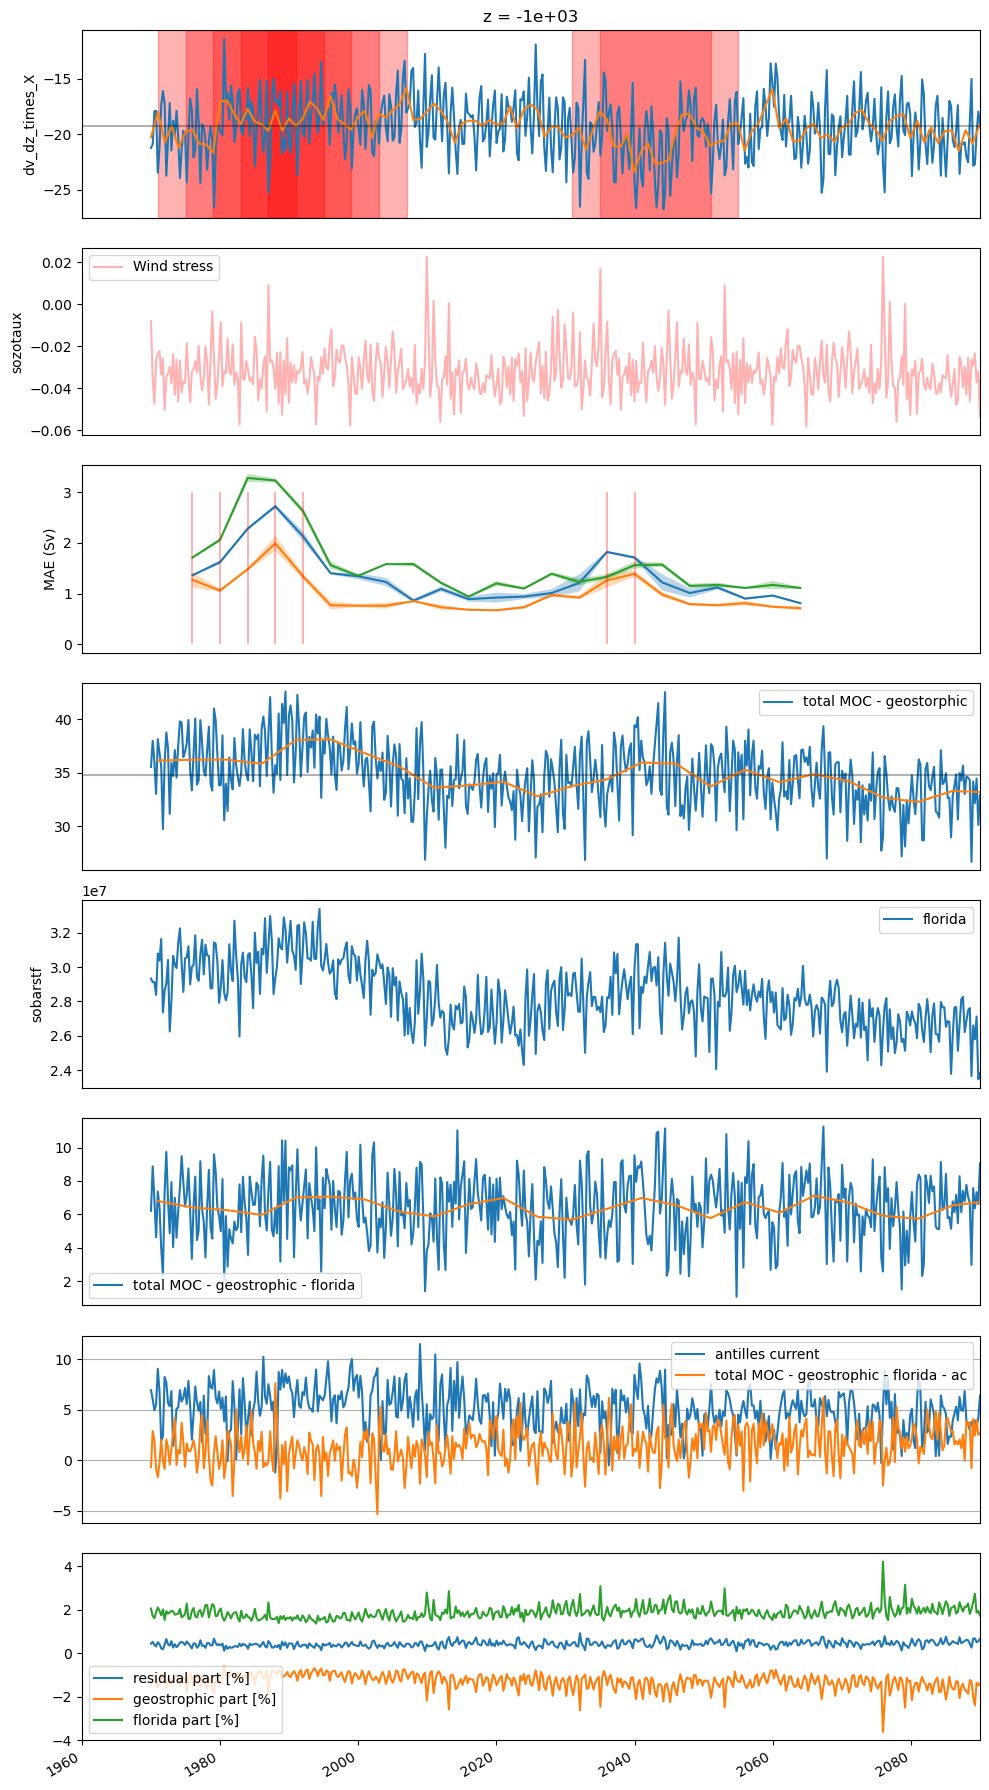

In [71]:
import matplotlib.pyplot as plt

# plot both plot but in a way that they do not share the yaxis 
#t_umo_obs.dv_dz_times_X.plot()
#wind_stress.mean(['x', 'y']).sozotaux.plot()

n_rows = 8
fig = plt.figure(figsize=(10,18))


## crossvalidation figure 
def year_to_datetime(year):
    return datetime(year, 1, 1)

## read the file

with open('../rapid-geostrophic-reconstruction/result_crossvalidation.txt', 'r') as f:
    lines = f.readlines()

looking_for = 'MAE'

v5_std = []
v5_std_mean_embed = []
v6 = []

for line in lines:

    if line.startswith('v6-wo'):
        splits = line.split(' ')
        years = splits[1]

        start_year = int(years.split('-')[0])

        if looking_for == 'R2':
            results = float(line.split('%')[0].split(' ')[-1])
            results_std = float(line.split('R2')[1].split(' ')[4].split('%')[0])
        elif looking_for == 'MAE':
            results = float(line.split('MAE')[1].split(' ')[2])
            results_std = float(line.split('MAE')[1].split(' ')[4][:-1])

        v5_std.append((year_to_datetime(start_year), results, results_std))
    elif line.startswith('v5-std-'):
        splits = line.split(' ')
        years = splits[1]

        start_year = int(years.split('-')[0])

        if looking_for == 'R2':
            results = float(line.split('%')[0].split(' ')[-1])
            results_std = float(line.split('R2')[1].split(' ')[4].split('%')[0])
        elif looking_for == 'MAE':
            results = float(line.split('MAE')[1].split(' ')[2])
            results_std = float(line.split('MAE')[1].split(' ')[4][:-1])

        v5_std_mean_embed.append((year_to_datetime(start_year), results, results_std))


    elif line.startswith('v6-aux'):
        splits = line.split(' ')
        years = splits[1]

        start_year = int(years.split('-')[0])

        if looking_for == 'R2':
            results = float(line.split('%')[0].split(' ')[-1])
            results_std = float(line.split('R2')[1].split(' ')[4].split('%')[0])
        elif looking_for == 'MAE':
            results = float(line.split('MAE')[1].split(' ')[2])
            results_std = float(line.split('MAE')[1].split(' ')[4][:-1])

        v6.append((year_to_datetime(start_year), results, results_std))
import numpy as np
v5_std = np.array(v5_std)
v5_std_mean_embed = np.array(v5_std_mean_embed)
v6 = np.array(v6)

import matplotlib.pyplot as plt
ax = fig.add_subplot(n_rows,1,3)


ax.plot(v5_std[:,0], v5_std[:,1], label='only ws,fc,ac')
ax.fill_between(v5_std[:,0], (v5_std[:,1] - v5_std[:,2]).astype(float), (v5_std[:,1] + v5_std[:,2]).astype(float), alpha = .3)
ax.plot(v5_std_mean_embed[:,0], v5_std_mean_embed[:,1], label='suster std mean embed')
ax.fill_between(v5_std_mean_embed[:,0], (v5_std_mean_embed[:,1] - v5_std_mean_embed[:,2]).astype(float), (v5_std_mean_embed[:,1] + v5_std_mean_embed[:,2]).astype(float), alpha = .3)
ax.plot(v6[:,0], v6[:,1], label='only argo mean')
ax.fill_between(v6[:,0], (v6[:,1] - v6[:,2]).astype(float), (v6[:,1] + v6[:,2]).astype(float), alpha = .3)

# ax.legend()


ax.set_xlabel('Start year')
if looking_for == 'R2':
    ax.set_ylabel('R2 (%)')
elif looking_for == 'MAE':
    ax.set_ylabel('MAE (Sv)')
ax.set_xlabel(None)
ax.set_xticks([])


ax.set_xlim(datetime(1960, 1, 1), datetime(2090, 1, 1))

for i in range(len(v5_std_mean_embed)):
    if v5_std_mean_embed[i,1] > 1:
        ax.vlines(v5_std_mean_embed[i,0], 0, 3, color = 'red', alpha = .3)
# ax.set_ylim(0,100)
ax = fig.add_subplot(n_rows,1,1)


t_umo_obs.dv_dz_times_X.plot(ax = ax)
t_umo_obs.dv_dz_times_X.resample(time = '365D').mean().plot(ax = ax)


ax.hlines(t_umo_obs.dv_dz_times_X.mean(), datetime(1960, 1, 1), datetime(2090, 1, 1), color = 'black', alpha = .3)


# draw a red background for the time period where the MAE in v5_std_mean_embed is larger than 1
for i in range(len(v5_std_mean_embed)):
    if v5_std_mean_embed[i,1] > 1:
        ax.axvspan(v5_std_mean_embed[i,0] - pd.DateOffset(years=5), v5_std_mean_embed[i,0] + pd.DateOffset(years=15), color = 'red', alpha = .3)

ax.set_xlim(datetime(1960, 1, 1), datetime(2090, 1, 1))
ax.set_xlabel(None)
ax.set_xticks([])

ax = fig.add_subplot(n_rows,1,2)
wind_stress.mean(['x', 'y']).sozotaux.plot(ax = ax, c = 'red', alpha = .3, label = 'Wind stress')
ax.set_xlabel(None)
ax.set_xticks([])

ax.legend()
ax.set_xlim(datetime(1960, 1, 1), datetime(2090, 1, 1))


ax = fig.add_subplot(n_rows,1,4)

# total_moc.sel(depthw = -1000, method='nearest').zomsfatl.plot(ax = ax)
(
    (total_moc.sel(depthw = -1000, method='nearest').zomsfatl - t_umo_obs.dv_dz_times_X) 
).plot(ax = ax, label = 'total MOC - geostorphic')
(
    (total_moc.sel(depthw = -1000, method='nearest').zomsfatl - t_umo_obs.dv_dz_times_X) 
).resample(time = '5y').mean().plot(ax = ax)
ax.hlines((total_moc.sel(depthw = -1000, method='nearest').zomsfatl - t_umo_obs.dv_dz_times_X).mean(), datetime(1960, 1, 1), datetime(2090, 1, 1), color = 'black', alpha = .3)
ax.set_title(None)
ax.set_xlim(datetime(1960, 1, 1), datetime(2090, 1, 1))
ax.set_xlabel(None)
ax.set_xticks([])
ax.legend()

ax = fig.add_subplot(n_rows,1,5)

florida_current.sobarstf.plot(ax = ax, label = 'florida')
ax.set_title(None)
ax.set_xlim(datetime(1960, 1, 1), datetime(2090, 1, 1))
ax.set_xlabel(None)
ax.set_xticks([])
ax.legend()

ax = fig.add_subplot(n_rows,1,6)

# total_moc.sel(depthw = -1000, method='nearest').zomsfatl.plot(ax = ax)
(
    (total_moc.sel(depthw = -1000, method='nearest').zomsfatl - t_umo_obs.dv_dz_times_X) -
    (florida_current.sobarstf / 1e6)
).plot(ax = ax, label = 'total MOC - geostrophic - florida')
(
    (total_moc.sel(depthw = -1000, method='nearest').zomsfatl - t_umo_obs.dv_dz_times_X) 
    - (florida_current.sobarstf / 1e6)
).resample(time = '5y').mean().plot(ax = ax)
# ax.hlines((total_moc.sel(depthw = -1000, method='nearest').zomsfatl - t_umo_obs.dv_dz_times_X).mean(), datetime(1960, 1, 1), datetime(2090, 1, 1), color = 'black', alpha = .3)
ax.set_title(None)
ax.set_xlim(datetime(1960, 1, 1), datetime(2090, 1, 1))
ax.set_xlabel(None)
ax.set_xticks([])
ax.legend()


ax = fig.add_subplot(n_rows,1,7)
(
    antilles_current.__xarray_dataarray_variable__
).plot(ax = ax, label = 'antilles current')
(
    (total_moc.sel(depthw = -1000, method='nearest').zomsfatl - t_umo_obs.dv_dz_times_X) -
    (florida_current.sobarstf / 1e6) - antilles_current.__xarray_dataarray_variable__
).plot(ax = ax, label = 'total MOC - geostrophic - florida - ac')

ax.grid()
ax.set_title(None)
ax.set_xlim(datetime(1960, 1, 1), datetime(2090, 1, 1))
ax.set_xlabel(None)
ax.set_xticks([])
ax.legend()


ax = fig.add_subplot(n_rows,1,8)

geostrophic_moc_part = t_umo_obs.dv_dz_times_X
total_moc_base_value = total_moc.sel(depthw = -1000, method='nearest').zomsfatl
florida_part = (florida_current.sobarstf / 1e6)

residual_part = total_moc_base_value - geostrophic_moc_part - florida_part


(np.sign(residual_part) * np.abs(residual_part) / total_moc_base_value).plot(ax = ax, label = 'residual part [%]')
(np.sign(geostrophic_moc_part) * np.abs(geostrophic_moc_part) / total_moc_base_value).plot(ax = ax, label = 'geostrophic part [%]')
(np.sign(florida_part) * np.abs(florida_part) / total_moc_base_value).plot(ax = ax, label = 'florida part [%]')

ax.set_title(None)
ax.set_xlim(datetime(1960, 1, 1), datetime(2090, 1, 1))
ax.set_xlabel(None)
ax.legend()


fig.tight_layout()

In [46]:
# calculate the covariance between the geostrophic part and the residual part
np.corrcoef(np.stack([geostrophic_moc_part.values, florida_part.values, residual_part.values], axis =0 ))
# np.corrcoef(np.stack([geostrophic_moc_part.values, (total_moc_base_value - geostrophic_moc_part).values], axis =0 ))

# calculate the pearson correlation between the geostrophic part and the residual part
import scipy
scipy.stats.pearsonr(geostrophic_moc_part.values, total_moc_base_value.values)

PearsonRResult(statistic=0.35164669130573595, pvalue=1.191798832835989e-15)

variance of total MOC 6.43
variance of geostrophic MOC 7.39
variance of total - geostrophic MOC 8.97
mutual information regression 0.30


/gxfs_home/geomar/smomw507/.conda/envs/amoc_recons/lib/python3.9/site-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


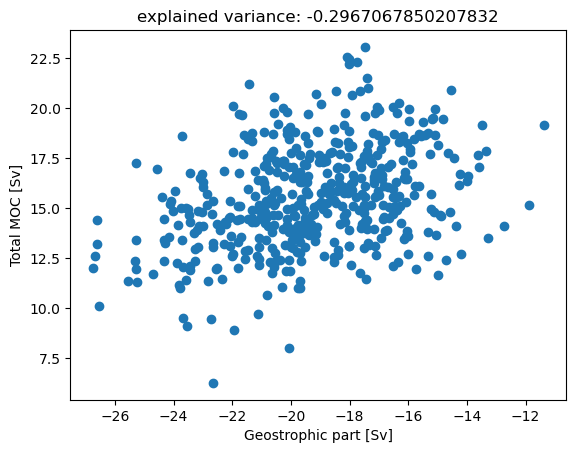

In [47]:
fig = plt.figure()
ax = fig.add_subplot(1,1,1)


ax.scatter(geostrophic_moc_part, total_moc_base_value)
ax.set_xlabel('Geostrophic part [Sv]')
ax.set_ylabel('Total MOC [Sv]')

ax.set_title(f'explained variance: {r2_score((total_moc_base_value - total_moc_base_value.mean()) / total_moc_base_value.std(), (geostrophic_moc_part - geostrophic_moc_part.mean()) / geostrophic_moc_part.std())}')  

print(f'variance of total MOC {total_moc_base_value.var().values:.2f}')
print(f'variance of geostrophic MOC {geostrophic_moc_part.var().values:.2f}')
print(f'variance of total - geostrophic MOC {(total_moc_base_value - geostrophic_moc_part).var().values:.2f}')
from sklearn.feature_selection import mutual_info_regression
print(f'mutual information regression {mutual_info_regression(geostrophic_moc_part.values.reshape(-1,1), (total_moc_base_value - geostrophic_moc_part).values.reshape(-1,1))[0]:.2f}')

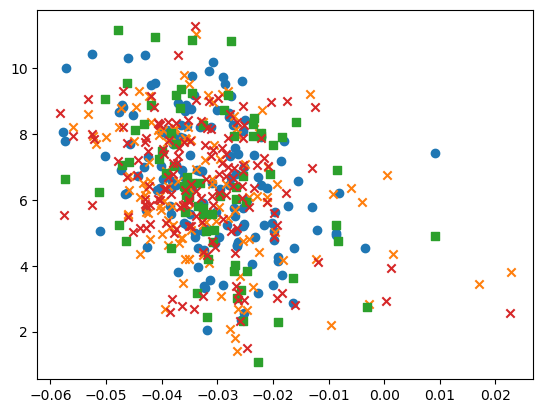

In [ ]:
## The MOC w/o geostorphic and fc gainst taux 

residual_moc = (
    (total_moc.sel(depthw = -1000, method='nearest').zomsfatl - t_umo_obs.dv_dz_times_X) -
    (florida_current.sobarstf / 1e6)
).values

taux = wind_stress.mean(['x', 'y']).sozotaux.values

fig = plt.figure()
ax = fig.add_subplot(1,1,1)

def plot_years(year_min, year_max, marker):

    year_mask = (total_moc.time.dt.year >= year_min) & (total_moc.time.dt.year < year_max) 
    ax.scatter(taux[year_mask], residual_moc[year_mask], marker = marker)

plot_years(1960, 2005, 'o')
plot_years(2005, 2036, 'x')
plot_years(2036, 2055, 's')
plot_years(2055, 2100, 'x')

[0.6348883  0.80070233]


/gxfs_home/geomar/smomw507/.conda/envs/amoc_recons/lib/python3.9/site-packages/threadpoolctl.py:1214: RuntimeWarning: 
Found Intel OpenMP ('libiomp') and LLVM OpenMP ('libomp') loaded at
the same time. Both libraries are known to be incompatible and this
can cause random crashes or deadlocks on Linux when loaded in the
same Python program.
Using threadpoolctl may cause crashes or deadlocks. For more
information and possible workarounds, please see
    https://github.com/joblib/threadpoolctl/blob/master/multiple_openmp.md

  warnings.warn(msg, RuntimeWarning)


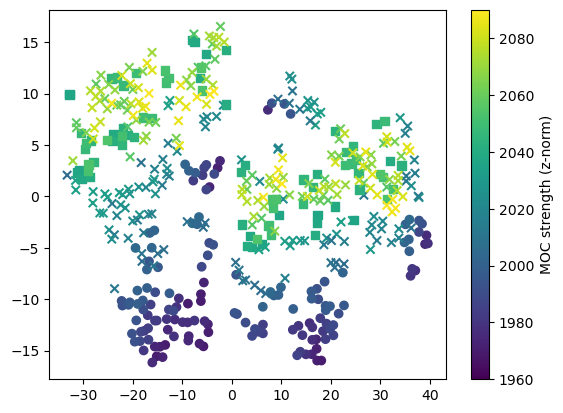

In [ ]:

from sklearn.decomposition import PCA
import numpy as np
import matplotlib.pyplot as plt

pca = PCA(n_components=2)

pca.fit(train_argo_means.detach().numpy())
train_reduced_values = pca.transform(train_argo_means.detach().numpy())
val_reduced_values = pca.transform(val_argo_means.detach().numpy())
test_reduced_values = pca.transform(test_argo_means.detach().numpy())

print(np.cumsum(pca.explained_variance_ratio_))

# do the dimension reduction with tsne instead of pca
from sklearn.manifold import TSNE
tsne = TSNE(n_components=2, perplexity=30, n_iter=1000, random_state=42)

reduced_values = tsne.fit_transform(
    np.concatenate([train_argo_means.detach().numpy(), val_argo_means.detach().numpy(), test_argo_means.detach().numpy()], axis = 0)
)

train_reduced_values = reduced_values[:len(train_argo_means)]
val_reduced_values = reduced_values[len(train_argo_means):len(train_argo_means) + len(val_argo_means)]
test_reduced_values = reduced_values[len(train_argo_means) + len(val_argo_means):]



def plot_inbetween_years(year_min, year_max, marker):
    train_mask = (train_years >= year_min) & (train_years < year_max)
    plt.scatter(train_reduced_values[train_mask,0], train_reduced_values[train_mask,1], 
                # c = train_moc_strength.detach().numpy(), 
                c = train_years[train_mask], vmin= 1960, vmax = 2090,
                marker=marker, label = 'Train')
    val_mask = (val_years >= year_min) & (val_years < year_max)
    plt.scatter(val_reduced_values[val_mask,0], val_reduced_values[val_mask,1], 
                # c = val_moc_strength.detach().numpy(), 
                c = val_years[val_mask], vmin= 1960, vmax = 2090,
                marker=marker, label = 'Validation')
    test_mask = (test_years >= year_min) & (test_years < year_max)
    plt.scatter(test_reduced_values[test_mask,0], test_reduced_values[test_mask,1], 
                # c = test_moc_strength.detach().numpy(),
                c = test_years[test_mask], vmin= 1960, vmax = 2090,
                marker=marker, label = 'Test')
    
plot_inbetween_years(1960, 2005, 'o')
plot_inbetween_years(2005, 2036, 'x')
plot_inbetween_years(2036, 2055, 's')
plot_inbetween_years(2055, 2100, 'x')

plt.colorbar(label = 'MOC strength (z-norm)')

# plt.legend()

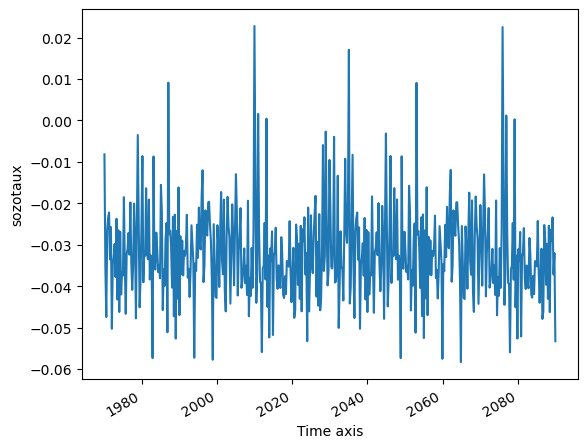

In [ ]:
wind_stress.sozotaux.mean(list('xy')).plot()

## Look into the geostoprhic velocity section to see differences 


In [12]:
from pathlib import Path
from xarray import open_mfdataset, open_dataset
def find_grid_files(grid_type, years, nest, model, delta_t, folder = 'output'): 
    experiment_path = Path('/gxfs_work/geomar/smomw355/model_data/ocean-only/')
    nest_part = '1_' if nest else '' 

    if len(grid_type) < 2:
        grid_type = f'grid_{grid_type}'

    grid_files = (experiment_path / model / 'nemo' / folder).glob(f'{nest_part}{model}_{delta_t}_*_*_{grid_type}.nc')
    grid_files = list(grid_files)
    
    result_files = []
    for file in grid_files:
        start_year = int(str(file).split('/')[-1].split('_')[- (3 + grid_type.count('_'))][:4])
        
        if (years[0] is None or start_year >= years[0]) and \
           (years[1] is None or start_year < years[1]):
            result_files.append(file)
    
    return sorted(result_files)

def load_dataset_from_grid_type(grid_type, years, nest, model, delta_t, chunks = {"time_counter" : 2,"y": 2, "x": None}, **kwargs):
    files_list = find_grid_files(grid_type, years, nest, model, delta_t, **kwargs)
    grid = open_mfdataset(
        files_list, # type: ignore
        chunks= chunks,
        combine='by_coords'
    )
    return grid

def load_masks(nest, model):

    if str.startswith(model, 'VIKING20X.L46-KFS003'):
        # All the mask for the long runs VIKING20X.L46-KFS003-2nd, ... are placed in the original experiment
        model = 'VIKING20X.L46-KFS003' 
    
    nest_part = '1_' if nest else ''
    
    mask_mesh = open_dataset(
        f'/gxfs_work/geomar/smomw355/model_data/ocean-only/{model}/nemo/suppl/{nest_part}mesh_mask.nc',
        decode_cf=False,
        # chunks={'y': 512, 'x':512},
    )
    mask_glo = open_dataset(
        f'/gxfs_work/geomar/smomw355/model_data/ocean-only/{model}/nemo/suppl/{nest_part}new_maskglo.nc',
        decode_cf=False,
        chunks={'Y':512, 'X':512}
    )

    mask_mesh = mask_mesh.squeeze()
    mask_glo = mask_glo.rename({'X':'x', 'Y':'y'}).squeeze() # Rename coordinates to have the same name as the data file
    
    return mask_mesh, mask_glo

In [2]:

from dask.distributed import Client

client = Client('tcp://10.0.4.104:8786')

In [3]:
client

<Client: 'tcp://10.0.4.104:8786' processes=100 threads=100, memory=1.09 TiB>

In [14]:

## Create a dictionary that maps from the simulation time data to the observation time within th goal to keep time windows of the size `time_smoothing` as one block

# Load the data
T = load_dataset_from_grid_type('T', (1970,None), True, 'VIKING20X.L46-KFS003', '1m', chunks = {"time_counter" : 6,"y": 10, "x": 1300})
T

<xarray.Dataset>
Dimensions:               (y: 2499, x: 2404, deptht: 46, time_counter: 648,
                           axis_nbounds: 2)
Coordinates:
    nav_lat               (y, x) float32 dask.array<chunksize=(10, 1300), meta=np.ndarray>
    nav_lon               (y, x) float32 dask.array<chunksize=(10, 1300), meta=np.ndarray>
  * deptht                (deptht) float32 3.047 9.454 ... 5.625e+03 5.875e+03
    time_centered         (time_counter) datetime64[ns] dask.array<chunksize=(6,), meta=np.ndarray>
  * time_counter          (time_counter) datetime64[ns] 1970-01-16T12:00:00 ....
Dimensions without coordinates: y, x, axis_nbounds
Data variables: (12/18)
    deptht_bounds         (time_counter, deptht, axis_nbounds) float32 dask.array<chunksize=(12, 46, 2), meta=np.ndarray>
    time_centered_bounds  (time_counter, axis_nbounds) datetime64[ns] dask.array<chunksize=(6, 2), meta=np.ndarray>
    time_counter_bounds   (time_counter, axis_nbounds) datetime64[ns] dask.array<chunksize=(6, 2), meta=np.ndarray>
    votemper              (time_counter, deptht, y, x) float32 dask.array<chunksize=(6, 46, 10, 1300), meta=np.ndarray>
    vosaline              (time_counter, deptht, y, x) float32 dask.array<chunksize=(6, 46, 10, 1300), meta=np.ndarray>
    sosstsst              (time_counter, y, x) float32 dask.array<chunksize=(6, 10, 1300), meta=np.ndarray>
    ...                    ...
    sohefldo              (time_counter, y, x) float32 dask.array<chunksize=(6, 10, 1300), meta=np.ndarray>
    somixhgt              (time_counter, y, x) float32 dask.array<chunksize=(6, 10, 1300), meta=np.ndarray>
    sowindsp              (time_counter, y, x) float32 dask.array<chunksize=(6, 10, 1300), meta=np.ndarray>
    sohefldp              (time_counter, y, x) float32 dask.array<chunksize=(6, 10, 1300), meta=np.ndarray>
    sowafldp              (time_counter, y, x) float32 dask.array<chunksize=(6, 10, 1300), meta=np.ndarray>
    sobowlin              (time_counter, y, x) float32 dask.array<chunksize=(6, 10, 1300), meta=np.ndarray>
Attributes:
    name:         /p/scratch/viking/schwarzkopf1/VIKING20X.L46/VIKING20X.L46-...
    description:  ocean T grid variables
    title:        ocean T grid variables
    Conventions:  CF-1.6
    timeStamp:    2020-Dec-19 08:20:04 GMT
    uuid:         84af2a2f-fbb6-49dc-bcad-3da2e42d5791
    history:      Tue Dec 22 10:56:31 2020: ncrcat 1_VIKING20X.L46-KFS003_1m_...
    NCO:          netCDF Operators version 4.9.6 (Homepage = http://nco.sf.ne...

In [15]:
T_slice = T.isel(y = 1273)

In [16]:
from gsw.density import rho


sigmai = rho(T_slice.vosaline, T_slice.votemper, T_slice.deptht)

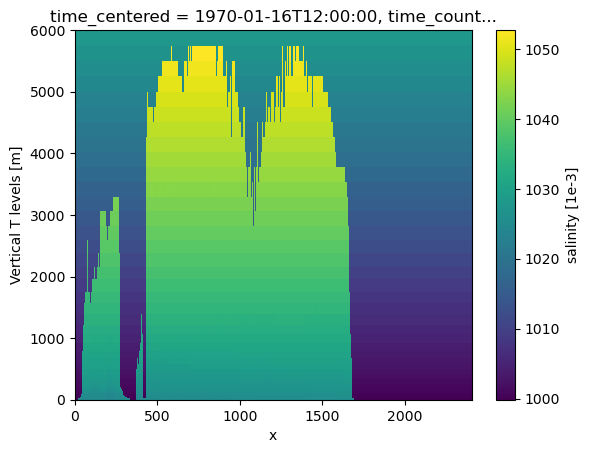

In [17]:
sigmai.isel(time_counter = 0).plot()

In [18]:
mask_mesh, mask_glo = load_masks(True, 'VIKING20X.L46-KFS003')


full_level = mask_mesh.e3t_0.rename({'z': 'deptht'}).isel(y = 1273).max('x')
half_level = mask_mesh.e3t_0.rename({'z': 'deptht'}).isel(y = 1273).max('x') / 2

In [19]:
masked_sigmai = sigmai.where(mask_mesh.tmask.isel(y = 1273).rename({'z': 'deptht'}))


In [20]:
masked_sigmai.to_netcdf('masked_sigmai_VIKING20X_KFS003-1st_70None.nc')

In [25]:
grav = 9.81
dphalflevel = masked_sigmai * grav * half_level
dplevel = masked_sigmai * grav * full_level

In [26]:
W_pressure_field = dplevel.cumsum('deptht').shift(deptht = 1) + dphalflevel

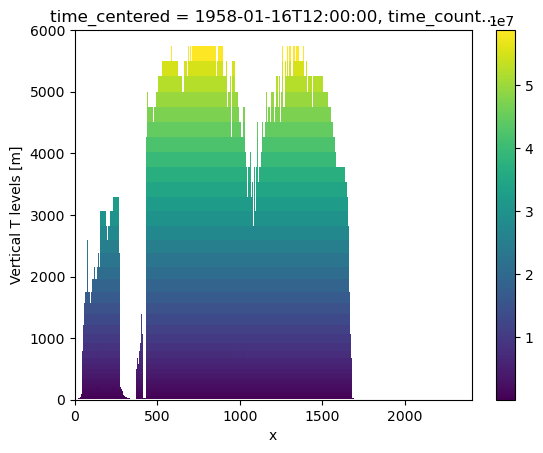

In [27]:
W_pressure_field.isel(time_counter = 0).plot()

In [28]:
zrho0 = 1025
zohr0 = 1 / zrho0

pressure_difference = (W_pressure_field.shift(x = 1) - W_pressure_field.shift(x = -1))

corriolis = mask_mesh.ff.isel(y = 1273)




In [29]:
masked_pressure_difference = pressure_difference.where(
    mask_mesh.isel(y = 1273).rename({'z': 'deptht'}).tmask * 
    mask_mesh.isel(y = 1273).rename({'z': 'deptht'}).tmask.shift(x = 1) * 
    mask_mesh.isel(y = 1273).rename({'z': 'deptht'}).tmask.shift(x = -1)
)

In [30]:
dvn = +1 * (zohr0 / corriolis) * masked_pressure_difference/ mask_mesh.e1v.isel(y = 1273)

In [31]:
import numpy as np

dataset = dvn.assign_coords(x = np.arange(dvn.x.shape[0])).isel(x = slice(430,1700)).load()

In [32]:
dataset

<xarray.DataArray (x: 1270, time_counter: 792, deptht: 46)>
array([[[        nan,  0.0317939 ,  0.05502076, ...,         nan,
                 nan,         nan],
        [        nan,  0.04003939,  0.0693939 , ...,         nan,
                 nan,         nan],
        [        nan,  0.0233174 ,  0.04062626, ...,         nan,
                 nan,         nan],
        ...,
        [        nan,  0.00277503,  0.00480994, ...,         nan,
                 nan,         nan],
        [        nan,  0.00707626,  0.01226782, ...,         nan,
                 nan,         nan],
        [        nan,  0.01086441,  0.018769  , ...,         nan,
                 nan,         nan]],

       [[        nan,  0.00591102,  0.01020247, ...,         nan,
                 nan,         nan],
        [        nan,  0.0074546 ,  0.01288197, ...,         nan,
                 nan,         nan],
        [        nan,  0.01807738,  0.03143845, ...,         nan,
                 nan,         nan],
...
        [        nan,         nan,         nan, ...,         nan,
                 nan,         nan],
        [        nan,         nan,         nan, ...,         nan,
                 nan,         nan],
        [        nan,         nan,         nan, ...,         nan,
                 nan,         nan]],

       [[        nan,         nan,         nan, ...,         nan,
                 nan,         nan],
        [        nan,         nan,         nan, ...,         nan,
                 nan,         nan],
        [        nan,         nan,         nan, ...,         nan,
                 nan,         nan],
        ...,
        [        nan,         nan,         nan, ...,         nan,
                 nan,         nan],
        [        nan,         nan,         nan, ...,         nan,
                 nan,         nan],
        [        nan,         nan,         nan, ...,         nan,
                 nan,         nan]]])
Coordinates:
    nav_lat        (x) float32 26.43 26.43 26.44 26.44 ... 26.46 26.46 26.46
    nav_lon        (x) float32 -76.95 -76.9 -76.85 -76.8 ... -13.6 -13.55 -13.5
  * deptht         (deptht) float32 3.047 9.454 16.36 ... 5.625e+03 5.875e+03
    time_centered  (time_counter) datetime64[ns] 1958-01-16T12:00:00 ... 2023...
  * time_counter   (time_counter) datetime64[ns] 1958-01-16T12:00:00 ... 2023...
  * x              (x) int64 430 431 432 433 434 ... 1695 1696 1697 1698 1699

In [33]:
dataset.to_netcdf('geo_v_VIKING20X_2nd_NoneNone.nc')

### Looking into the differences 

In [197]:
import xarray as xr
# geov = xr.open_dataset('geo_v_VIKING20X_1st_70None.nc')
geov = xr.open_dataset('masked_sigmai_VIKING20X_KFS003-1st_70None.nc')
geov2 = xr.open_dataset('masked_sigmai_VIKING20X_KFS003-2nd_NoneNone.nc')

In [198]:
geov = geov.resample(time_counter = '90D').mean()
geov2 = geov2.resample(time_counter = '90D').mean()

In [199]:
import pandas as pd
t_delta = geov.time_counter.max() - geov2.time_counter.min() + pd.Timedelta('90D')

geov2['time_counter'] = geov2.time_counter + t_delta

geov = xr.concat([geov, geov2], dim = 'time_counter')

In [200]:
geov = geov.sel(deptht = slice(0,2000)).isel(x = slice(430,1700))

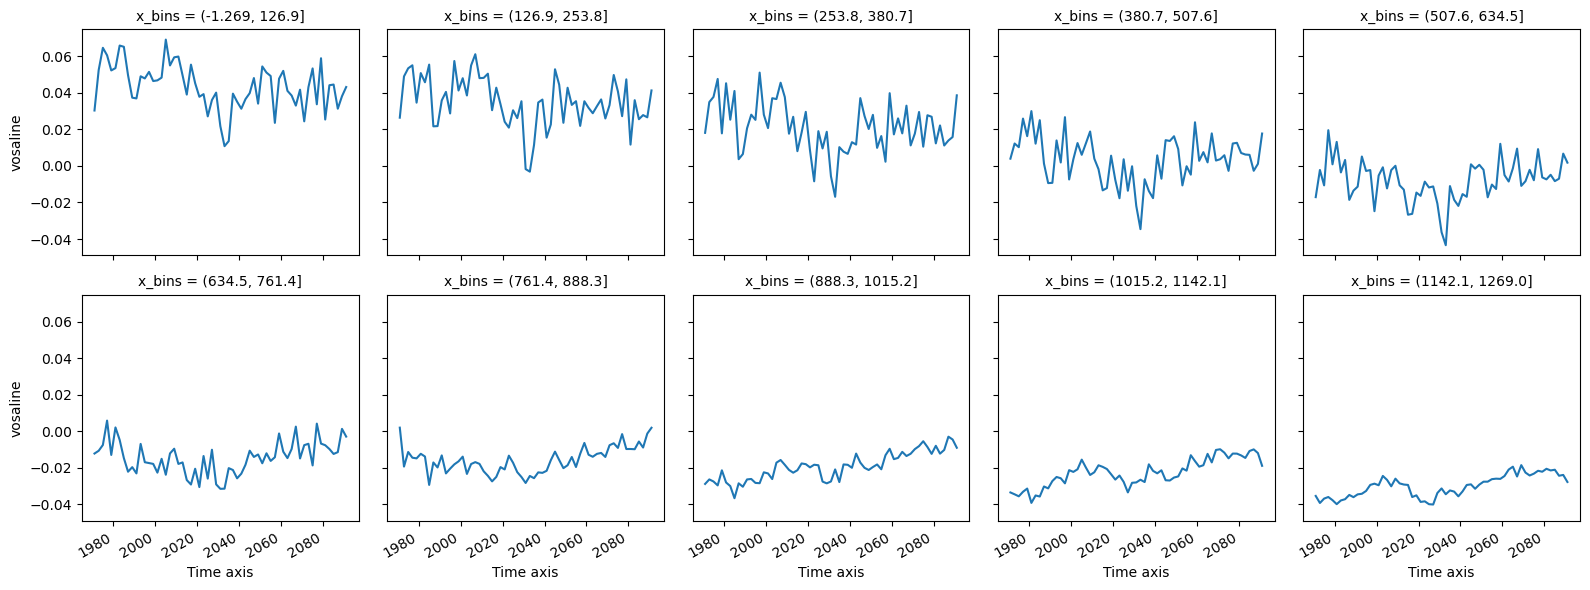

In [432]:
depth_i = -5
(
geov.isel(deptht = depth_i).vosaline.groupby_bins('x', 10).mean().resample(time_counter = '2Y').mean()
- geov.isel(deptht = depth_i).vosaline.mean('x').mean('time_counter')
).plot(x='time_counter', col = 'x_bins', col_wrap = 5)

In [201]:
pca_values = geov.vosaline.transpose('time_counter', 'deptht', 'x').values

In [6]:
from scipy.ndimage import gaussian_filter

In [87]:
import numpy as np
pca_values = gaussian_filter(
    pca_values, sigma = (1,21),
    axes = (1,2)
)

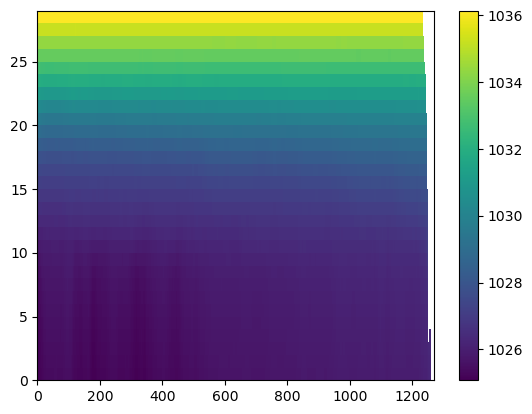

In [73]:
import matplotlib.pyplot as plt
fig = plt.figure()
ax = fig.add_subplot(1,1,1)

sigmai = ax.pcolormesh(pca_values[0])

plt.colorbar(sigmai)

In [8]:
import numpy as np
pca_values = pca_values.reshape(geov.time_counter.shape[0], -1)
pca_mask = np.isnan(pca_values).any(axis = 0)


pca_values = pca_values[:,~pca_mask]

[0.84450179 0.89969073]


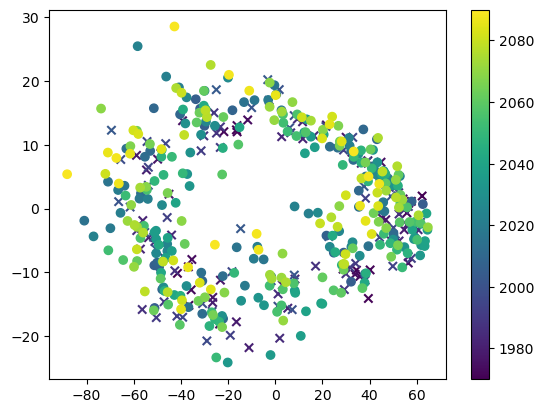

In [9]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
pca = PCA(n_components=2)

pca.fit(pca_values)

reduced_values = pca.transform(pca_values)

fig = plt.figure()
ax = fig.add_subplot(1,1,1)

first_mask = geov.time_counter.dt.year < 2005

scatter = ax.scatter(reduced_values[first_mask,0], reduced_values[first_mask,1],marker = 'x', c = geov.time_counter.dt.year[first_mask], vmin = 1970, vmax = 2090)
scatter = ax.scatter(reduced_values[~first_mask,0], reduced_values[~first_mask,1],marker = 'o', c = geov.time_counter.dt.year[~first_mask], vmin = 1970, vmax = 2090)
plt.colorbar(scatter)

print(np.cumsum(pca.explained_variance_ratio_))

In [12]:
old_img = None
img = None
for i in np.linspace(-20,20,5):

    if old_img is not None:
        fig = plt.figure()
        ax = fig.add_subplot(1,1,1)


        img = np.full((geov.deptht.shape[0] * geov.x.shape[0]), fill_value= np.nan)
        img[~pca_mask] = pca.inverse_transform([[0,i]])[0]

        img = img.reshape(geov.deptht.shape[0], geov.x.shape[0])


        print(np.nanmin(img))
        diff = ax.pcolormesh(

            img if old_img is None else img - old_img,
            vmin = -2, vmax = .2
        )
        plt.colorbar(diff)
    old_img = img

[0.93264109 0.98470272]


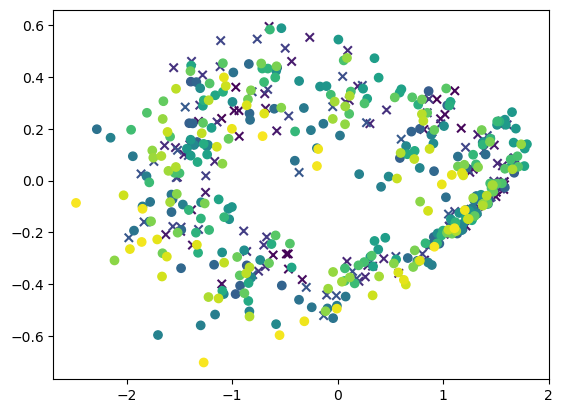

In [13]:
from sklearn.decomposition import PCA

pca_values_profiles = geov.vosaline.mean('x').values

pca = PCA(n_components=2)

reduced_values = pca.fit_transform(pca_values_profiles)


fig = plt.figure()
ax = fig.add_subplot(1,1,1) 

first_mask = geov.time_counter.dt.year < 2005
ax.scatter(reduced_values[first_mask, 0], reduced_values[first_mask, 1], c = geov.time_counter.dt.year[first_mask], marker = 'x', vmin = 1970, vmax = 2090)
ax.scatter(reduced_values[~first_mask, 0], reduced_values[~first_mask, 1], c = geov.time_counter.dt.year[~first_mask], marker = 'o', vmin = 1970, vmax = 2090)


print(np.cumsum(pca.explained_variance_ratio_))

[0.93315216 0.9853103 ]


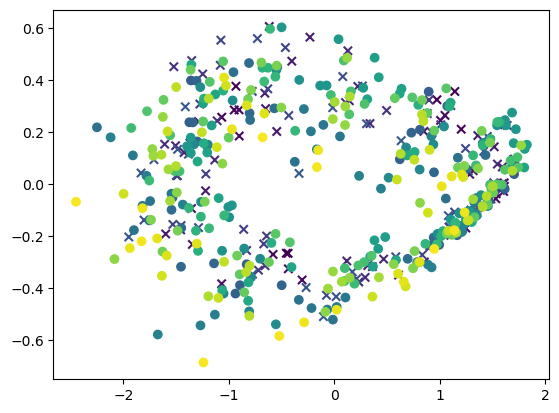

In [14]:
## Fitting the PCA only to the years after 2005


pca_values_profiles = geov.vosaline.mean('x').values

pca = PCA(n_components=2)
first_mask = geov.time_counter.dt.year < 2005

pca.fit(pca_values_profiles[~first_mask])

reduced_values = pca.transform(pca_values_profiles)


fig = plt.figure()
ax = fig.add_subplot(1,1,1) 

ax.scatter(reduced_values[first_mask, 0], reduced_values[first_mask, 1], c = geov.time_counter.dt.year[first_mask], marker = 'x', vmin = 1970, vmax = 2090)
ax.scatter(reduced_values[~first_mask, 0], reduced_values[~first_mask, 1], c = geov.time_counter.dt.year[~first_mask], marker = 'o', vmin = 1970, vmax = 2090)


print(np.cumsum(pca.explained_variance_ratio_))

In [136]:

import pickle as pckl

with open('../rapid-geostrophic-reconstruction/datasets/smoothing_90_days/argo_after_2012/base_sample/time_mapping_dict_1st_70None.pickle', 'rb') as f:
    dataset = pckl.load(f)

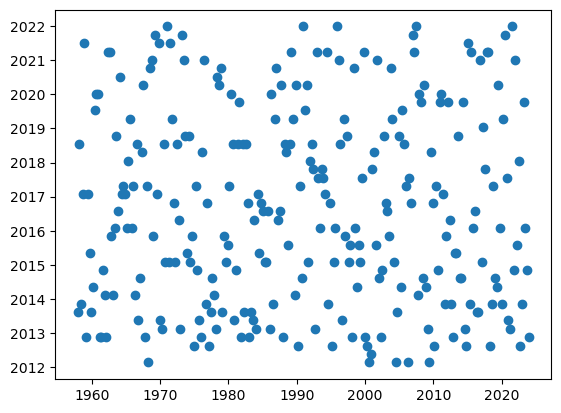

In [140]:
fig = plt.figure()
ax = fig.add_subplot(1,1,1)

ax.scatter(list(dataset.keys()), list(dataset.values()))

### Using the reconstruction dataset

In [54]:
import xarray as xr
from pathlib import Path
dataset_path = Path(f'../rapid-geostrophic-reconstruction/datasets/smoothing_90_days/argo_after_2012/base_sample/')


ds = xr.open_dataset(dataset_path / 'ds_argo_viking_KFS003-1st_70None.nc')
ds2 = xr.open_dataset(dataset_path / 'ds_argo_viking_KFS003-2nd_NoneNone.nc')

ds = ds.resample(time = '90D').mean()
ds2 = ds2.resample(time = '90D').mean()


t_delta = ds.time.max() - ds2.time.min() + pd.Timedelta('90D')

ds2['time'] = ds2.time + t_delta

ds = xr.concat([ds, ds2], dim = 'time')
ds = ds.sel(z = slice(-2000, None))
ds = ds.sel(time = slice('1970', '2085'))

/gxfs_home/geomar/smomw507/.conda/envs/amoc_recons/lib/python3.9/site-packages/xarray/coding/times.py:254: RuntimeWarning: invalid value encountered in cast
  flat_num_dates_ns_int = (flat_num_dates * _NS_PER_TIME_DELTA[delta]).astype(
/gxfs_home/geomar/smomw507/.conda/envs/amoc_recons/lib/python3.9/site-packages/xarray/coding/times.py:254: RuntimeWarning: invalid value encountered in cast
  flat_num_dates_ns_int = (flat_num_dates * _NS_PER_TIME_DELTA[delta]).astype(


[0.73164762 0.92248178]


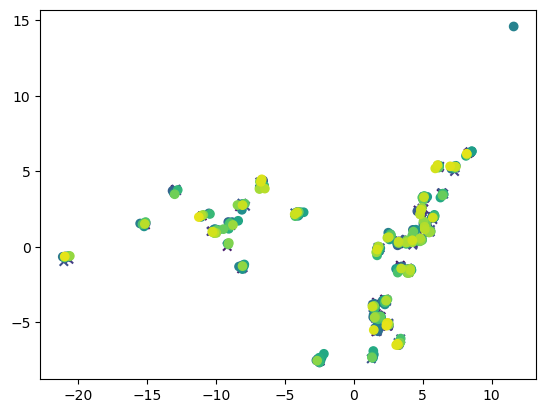

In [56]:
from sklearn.decomposition import PCA
pca_values = ds.mean('pos').rho.sel(z=slice(-2000, None)).values

pca = PCA(n_components=2)

reduced_values = pca.fit_transform(pca_values)

fig = plt.figure()

ax = fig.add_subplot(1,1,1)

first_mask = ds.time.dt.year < 2005
ax.scatter(reduced_values[first_mask,0], reduced_values[first_mask,1], c = ds.time.dt.year[first_mask], marker = 'x', vmin = 1970, vmax = 2090)
ax.scatter(reduced_values[~first_mask,0], reduced_values[~first_mask,1], c = ds.time.dt.year[~first_mask], marker = 'o', vmin = 1970, vmax = 2090)
print(np.cumsum(pca.explained_variance_ratio_))

In [57]:
def filter_ds_argo_data(ds_argo_merged_10days, deep_argo = False):

    

    # VIKING contains more detailed information in the upper layers as the Argo dataset
    # Argo only measures each 20 meters while VIKING has measurments at 0, 3, 9, 12 ... meters

    boundaries = np.arange(-10000, 1, 20) + 10
    depth_grouped = ds_argo_merged_10days.groupby_bins('z', boundaries).mean()
    depth_grouped = depth_grouped.where(ds_argo_merged_10days.z.groupby_bins('z', boundaries).count() > 0)


    ds_argo_merged_10days = depth_grouped.assign_coords(z_bins = ('z_bins', np.arange(-10000, 1, 20)[1:])).rename({'z_bins': 'z'}).sel(z = ds_argo_merged_10days.z, method = 'nearest').assign_coords(z = ds_argo_merged_10days.z).transpose('time', 'pos', 'z')

    # We only take the first 2000 meters depth
    if not deep_argo:
        ds_argo_merged_10days = ds_argo_merged_10days.where(ds_argo_merged_10days.z > -2000, drop = True)

    ds_argo_merged_10days = ds_argo_merged_10days.where((ds_argo_merged_10days.salinity > 0).all('z'))
    # ds_argo_merged_10days = ds_argo_merged_10days.where((ds_argo_merged_10days.z <= -1500) | (ds_argo_merged_10days.z > -100) , drop = True)
    # ds_argo_merged_10days = ds_argo_merged_10days.where((ds_argo_merged_10days.z <= -1500) , drop = True)

    ds_argo_merged_10days = ds_argo_merged_10days.sortby('z')

    return ds_argo_merged_10days

ds_filtered = filter_ds_argo_data(ds)

In [58]:
train_indices = np.argwhere((ds_filtered.time.dt.year >= 2005).values).squeeze()

In [59]:
# rho_mean = ds.where(ds.profile_mask).isel(time = train_indices).mean(['time', 'pos']).rho
# rho_std = ds.where(ds.profile_mask).isel(time = train_indices).std(['time', 'pos']).rho



rho_mean = ds_filtered.where(ds_filtered.profile_mask).isel(time = train_indices).mean(['time', 'pos']).rho
rho_std = ds_filtered.where(ds_filtered.profile_mask).isel(time = train_indices).std(['time', 'pos']).rho

In [60]:
# grouped_std = rho_std.groupby_bins('z', [-2000, -800,-200, -100,-50, 0], labels = [-1400,-500,-150,-75,-25]).mean()
# rho_std = grouped_std.sel(z_bins = rho_std.z, method = 'nearest')


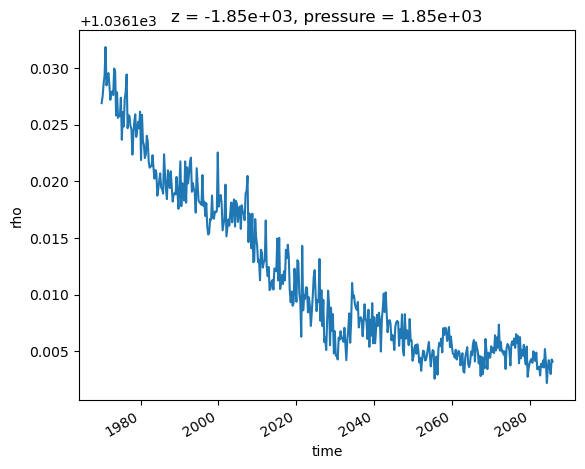

In [61]:
ds_filtered.mean('pos').isel(z = 0).rho.plot()

In [62]:
rho_mean.values, rho_std.values

(array([1036.10737072, 1035.2038073 , 1034.334508  , 1033.49087329,
        1032.68303705, 1031.92976896, 1031.21737189, 1030.51119228,
        1029.8446616 , 1029.19899222, 1028.6110118 , 1028.12342575,
        1027.72420808, 1027.39306725, 1027.11213876, 1026.86658255,
        1026.64642282, 1026.44712976, 1026.26729485, 1026.09881578,
        1025.92969832, 1025.6644353 , 1025.6644353 , 1025.35623968,
        1025.35623968, 1025.16697055, 1025.16697055, 1025.050705  ,
        1025.050705  ]),
 array([0.00732364, 0.00971198, 0.01514746, 0.02394663, 0.03031711,
        0.0302946 , 0.03265992, 0.08015748, 0.14567146, 0.21150742,
        0.26012604, 0.26519349, 0.24874657, 0.22867618, 0.21548627,
        0.21597016, 0.23274597, 0.26231343, 0.29768329, 0.33266521,
        0.3711556 , 0.4608253 , 0.4608253 , 0.6139188 , 0.6139188 ,
        0.71373665, 0.71373665, 0.75302811, 0.75302811]))

In [63]:
from copy import deepcopy
def standardize_rho(ds_pos, rho_mean=None, rho_std=None):
    ds_pos = deepcopy(ds_pos)
    ds_pos["rho"] = (ds_pos["rho"] - rho_mean) / rho_std
    return ds_pos

rho_std = standardize_rho(ds_filtered, rho_mean, rho_std)

In [64]:
coefficients = rho_std.rho.mean('pos').isel(time = train_indices).polyfit('time', 1).polyfit_coefficients
rho_std = rho_std.assign(
    rho_linear = (coefficients.sel(degree = 1) * rho_std.rho.mean('pos').time.astype(int) + coefficients.sel(degree = 0))
)

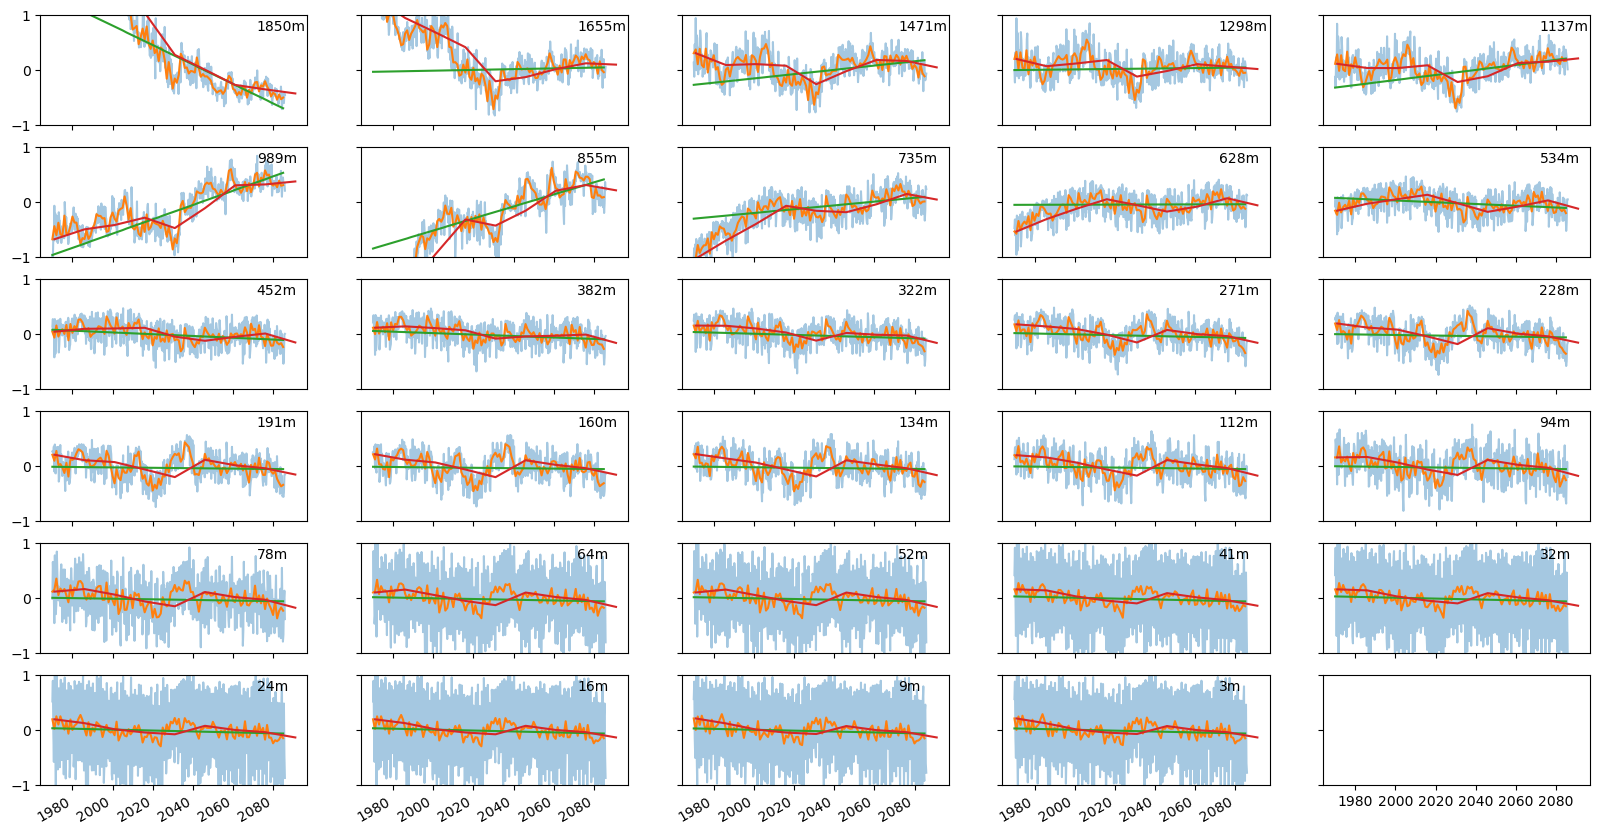

In [65]:
# where((np.abs(rho_std.mean('pos')) > 1).any('time').rho, drop = True). \
# rho.mean('pos').isel(z = slice(None, None, 1)).resample(time = '365D').mean().plot.line(x = 'time', col="z", col_wrap=5) \
# rho_plotvalues.resample(time = '365D').mean().plot.line(x = 'time', col="z", col_wrap=5, hue = 'features') 


fig, ax = plt.subplots(6, 5, sharex=True, sharey = True, figsize=(20, 10))


for _t, _ax in zip(range(rho_std.sizes["z"]), ax.flatten()):
    rho_std.rho.isel(z=_t).mean('pos').resample(time = '90D').mean().plot(ax=_ax, alpha = .4) 
    rho_std.rho.isel(z=_t).mean('pos').resample(time = '365D').mean().plot(ax=_ax) 
    rho_std.rho_linear.isel(z=_t).resample(time = '365D').mean().plot(ax=_ax) 

    rho_std.rho.isel(z=_t).mean('pos').resample(time = '15y').mean().plot(ax=_ax) 

    # (
    #     rho_std.rho.isel(z=_t).var('pos').resample(time = '365D').mean() - 
    #     rho_std.rho_linear.isel(z=_t).resample(time = '365D').mean()
    #     # rho_std.rho.isel(z=_t).mean('pos').resample(time = '25y').mean().interp(time = rho_std.resample(time = '365D').mean().time, method = 'linear')
    # ).plot(ax=_ax) 
    _ax.set_ylabel(None)
    _ax.set_xlabel(None)
    _ax.set_title(None)

    _ax.text(0.81, 0.86, f'{abs(rho_std.z.isel(z=_t).values):.0f}m', transform=_ax.transAxes)

    _ax.set_ylim(-1, 1)




1850m: True
1655m: True
1471m: True
1298m: True
1137m: False
989m: True
855m: True
735m: True
628m: True
534m: True
452m: True
382m: True
322m: True
271m: True
228m: True
191m: True
160m: True
134m: True
112m: True
94m: True
78m: True
64m: False
52m: False
41m: False
32m: False
24m: False
16m: False
9m: False
3m: False
[2, 3, 4, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28]


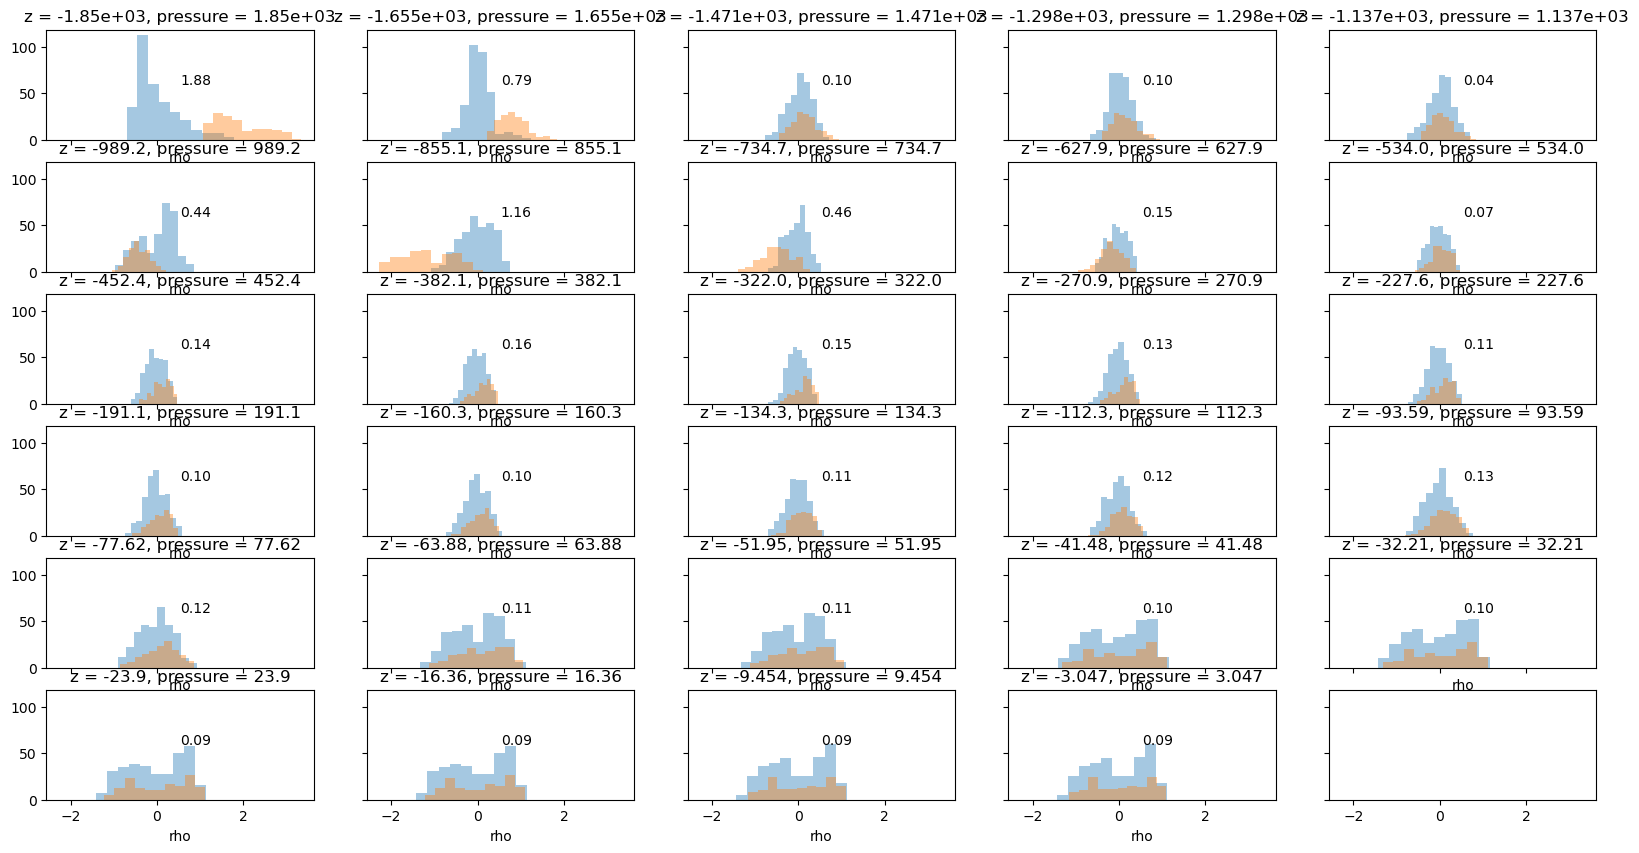

In [66]:
fig, ax = plt.subplots(6, 5, sharex=True, sharey = True, figsize=(20, 10))

valid_indices = []
for _t, _ax in zip(range(rho_std.sizes["z"]), ax.flatten()):
    rho_std.rho.isel(z=_t).mean('pos').sel(time = slice('2005', None)).resample(time = '90D').mean().plot.hist(ax=_ax, alpha = .4)
    rho_std.rho.isel(z=_t).mean('pos').sel(time = slice(None, '2005')).resample(time = '90D').mean().plot.hist(ax=_ax, alpha = .4)

    # import a ttest and test if the two distributions are different
    from scipy.stats import ttest_ind, wasserstein_distance

    t_stat, p_value = ttest_ind(
        rho_std.rho.isel(z=_t).mean('pos').sel(time = slice('2005', None)).resample(time = '90D').mean().values,
        rho_std.rho.isel(z=_t).mean('pos').sel(time = slice(None, '2005')).resample(time = '90D').mean().values
    )
    
    # print if the two distributions are different under a 95% confidence interval
    print(f'{abs(rho_std.z.isel(z=_t).values):.0f}m: {p_value < 0.01}')

    distance = wasserstein_distance(
        rho_std.rho.isel(z=_t).mean('pos').sel(time = slice('2005', None)).resample(time = '90D').mean().values,
        rho_std.rho.isel(z=_t).mean('pos').sel(time = slice(None, '2005')).resample(time = '90D').mean().values
    )

    _ax.text(0.5, 0.5, f'{distance:.2f}', transform=_ax.transAxes)

    if distance < .2:
        valid_indices.append(_t)

print(valid_indices)


[0.72156576 0.87852213]


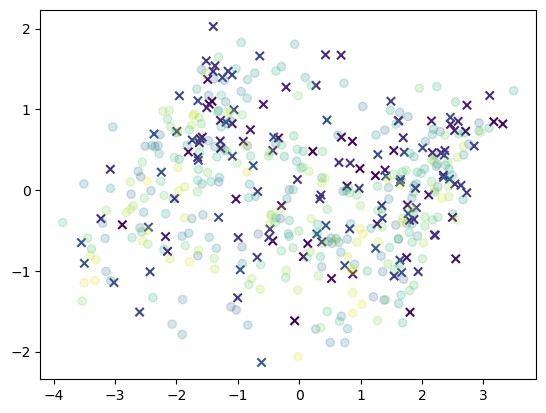

In [68]:

pca_values = rho_std.mean('pos').rho.isel(z = [2, 3, 4, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28]).values
# sel(z=slice(-2000, None)).values

pca = PCA(n_components=2)

reduced_values = pca.fit_transform(pca_values)

fig = plt.figure()

ax = fig.add_subplot(1,1,1)

first_mask = rho_std.time.dt.year < 2005
ax.scatter(reduced_values[first_mask,0], reduced_values[first_mask,1], c = rho_std.time.dt.year[first_mask], marker = 'x', vmin = 1970, vmax = 2090)
ax.scatter(reduced_values[~first_mask,0], reduced_values[~first_mask,1], c = rho_std.time.dt.year[~first_mask], marker = 'o', vmin = 1970, vmax = 2090 , alpha = .2)
print(np.cumsum(pca.explained_variance_ratio_))

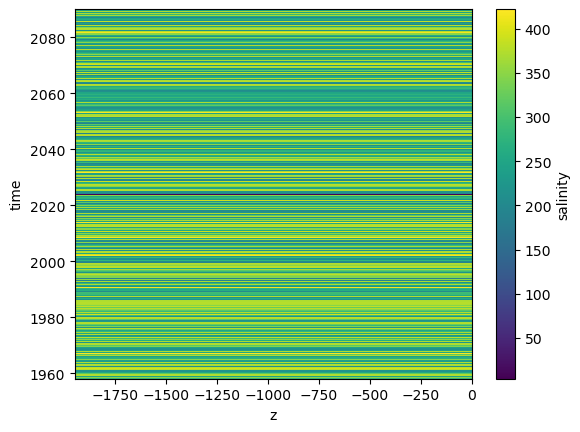

In [120]:
(ds_filtered.salinity > 0).sum('pos').plot()

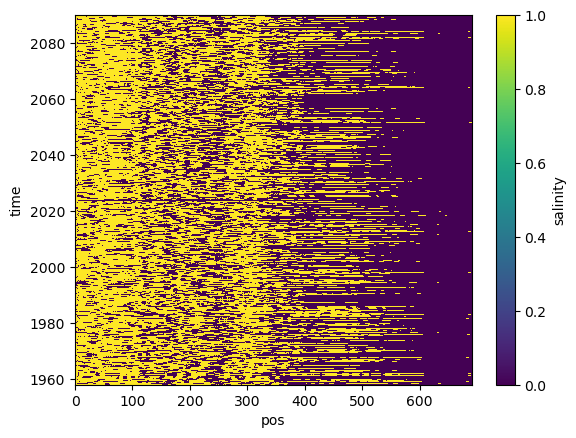

In [118]:
import hvplot.xarray

(ds_filtered.salinity > 0).all('z').plot()

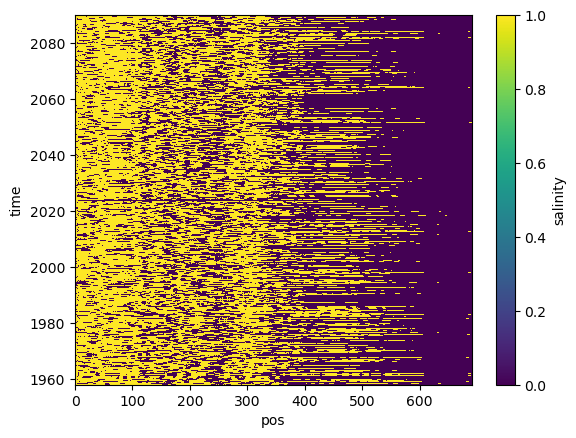

In [119]:
(ds_filtered.salinity > 0).any('z').plot()


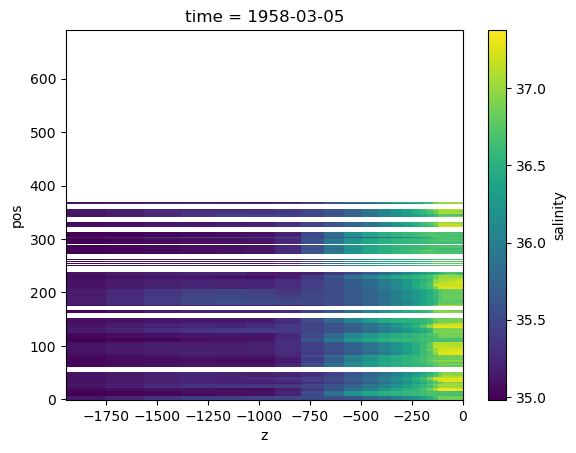

In [126]:
ds.where((ds.salinity > 0).all('z')).isel(time = 0).salinity.plot()

(array([2.63010e+04, 1.46015e+05, 1.45824e+05, 1.13190e+05, 1.03401e+05,
        8.36930e+04, 7.76020e+04, 7.10230e+04, 6.39690e+04, 6.59060e+04,
        5.69860e+04, 4.54420e+04, 3.46930e+04, 2.67400e+04, 2.69550e+04,
        3.23600e+04, 3.34160e+04, 2.97460e+04, 2.56570e+04, 2.25160e+04,
        2.14400e+04, 2.33140e+04, 2.59120e+04, 2.94870e+04, 2.70970e+04,
        2.13370e+04, 2.19580e+04, 2.46860e+04, 2.58690e+04, 2.62790e+04,
        2.68190e+04, 2.45210e+04, 2.33960e+04, 2.38630e+04, 2.50790e+04,
        2.47460e+04, 2.47280e+04, 2.51850e+04, 2.54480e+04, 2.57430e+04,
        2.53330e+04, 2.53490e+04, 2.66750e+04, 2.84930e+04, 2.88240e+04,
        2.97290e+04, 3.00070e+04, 3.22760e+04, 3.34740e+04, 3.63870e+04,
        3.90350e+04, 4.28260e+04, 4.87000e+04, 5.25160e+04, 5.94820e+04,
        6.83140e+04, 7.68700e+04, 8.75300e+04, 9.66510e+04, 1.04799e+05,
        1.09932e+05, 1.10876e+05, 1.10846e+05, 1.09017e+05, 1.08566e+05,
        1.07912e+05, 1.06889e+05, 1.03649e+05, 9.86

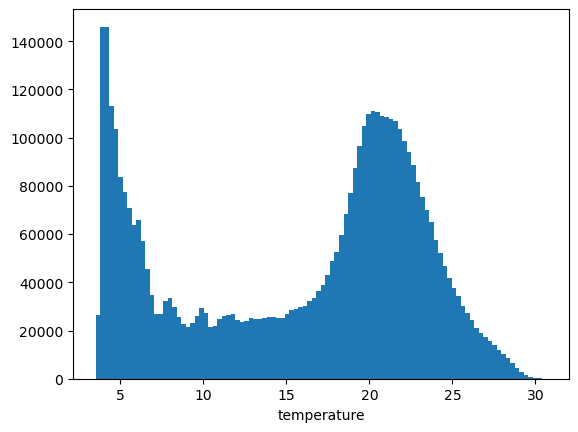

In [137]:

# make a histogram of the salinity values

ds_filtered.temperature.plot.hist(bins = 100)